In [13]:
from collections import defaultdict
import re
import os
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from PIL import Image
from torchvision import transforms
from classifier_model import AIClassifier
import sklearn
import numpy as np

In [14]:
"""
Prereqs: download 10 vids/directory in all_dirs via download_ff_data.sh
"""
def group_by_video(directory):
    groups = defaultdict(list)
    for video_name in os.listdir(directory):
        video_path = os.path.join(directory, video_name)
        if not os.path.isdir(video_path):
            continue
        frames = sorted(f for f in os.listdir(video_path) if f.endswith('.png'))
        if frames:
            # change: doesn't prepend video name to frame filename
            groups[video_name] = [f for f in frames]
    
    result = []
    for key, frames in groups.items():
        result.append([key, frames])
    return result


def extract_original_vid(path: str):
    # use this to ensure that original videos and their manipulated derivatives 
    # are all in the same side of the split, so that the model is only evaluated on data 
    # it hasn't seen before

    name = Path(path).name
    
    # matches DFD fakes, first number is the og, then name should match
    m = re.fullmatch(r'(\d+)_\d+__(.+)__([A-Z0-9]{8})', name)
    if m:
        return f"{m.group(1)}__{m.group(2)}"

    # DFD reals
    m = re.fullmatch(r'(\d+)__(.+)', name)
    if m:
        return f"{m.group(1)}__{m.group(2)}" 

    # rest of the fakes, first number is the target
    m = re.fullmatch(r'(\d+)_(\d+)', name)
    if m:
        return m.group(1)   

    # FF reals
    if re.fullmatch(r'\d+', name):
        return name

    return None 

In [109]:
all_dirs = ['FF_data20/real/original_sequences/youtube/c40/images', 
            'FF_data20/fake/manipulated_sequences/Deepfakes/c40/images',
            'FF_data20/DFD_real/original_sequences/actors/c40/images',
            'FF_data20/DFD_fake/manipulated_sequences/DeepFakeDetection/c40/images',
            'FF_data20/Face2Face/manipulated_sequences/Face2Face/c40/images',
            'FF_data20/FaceSwap/manipulated_sequences/FaceSwap/c40/images',
            'FF_data20/NeuralTextures/manipulated_sequences/NeuralTextures/c40/images'
            ]

'''
0 - Authentic
1 - Deepfake
'''
# same thing as the original version, but combines the root dir and vidpath to
# make ID'ing unique vids easier
# skip is the increment of frames btwn frames in a clip
def create_datamap(all_dirs, frames_per_clip=10, skip=1):
    data = {
        'video_path': [],
        "video_name": []
    }
    for i in range(10):
        data['frame_' + str(i)] = []
    
    data['label'] = []

    for dir in all_dirs:
        label = 1
        if 'original' in dir:
            label = 0
        # list of videos in dir, along with a list of frame filenames with them 
        #[[vid, [vid/fr1.png, vid/fr2.png, ...]], ...]
        video_map = group_by_video(dir)
        for video, frames in video_map:
            i = 0
            for j in range(frames_per_clip * skip, len(frames), frames_per_clip * skip):
                if skip == 1:
                    split = frames[i:j]
                else:
                    split = [frames[idx] for idx in range(i, j, skip)]
                i = j
                data['video_path'].append(os.path.join(dir, video))
                data["video_name"].append(video)
                data['label'].append(label)
                for k in range(len(split)):
                    data['frame_' + str(k)].append(split[k])
    

    return data

source_dir = "dataset_50v_80_20"
remake_data = False
if remake_data:
    data_map = create_datamap(all_dirs)
    df = pd.DataFrame(data_map)
    df['original_vid'] = df['video_name'].apply(extract_original_vid)
    os.makedirs(source_dir, exist_ok=True)

    df.to_csv(os.path.join(source_dir, 'full_dataset.csv'), index=False) # for testing dataset
    vidnames = list(set(df["original_vid"]))
    train_vids, test_vids = train_test_split(vidnames, test_size=0.2)
    train_frames = df.loc[[og_vid in train_vids for og_vid in df["original_vid"]]]
    test_frames = df.loc[[og_vid in test_vids for og_vid in df["original_vid"]]]
    train_frames.to_csv(os.path.join(source_dir, "train_split.csv"), index=False)
    test_frames.to_csv(os.path.join(source_dir, "test_split.csv"), index=False)
else:
    df = pd.read_csv(os.path.join(source_dir, "full_dataset.csv"))
    vidnames = list(set(df["original_vid"]))
    train_frames = pd.read_csv(os.path.join(source_dir, "train_split.csv"))
    test_frames = pd.read_csv(os.path.join(source_dir, "test_split.csv"))
print(f"Num videos: {len(vidnames)}")
print(f"Total clips = {len(df)}")
print(f"Train clips: {len(train_frames)}   Test clips: {len(test_frames)}")

Num videos: 140
Total clips = 820
Train clips: 654   Test clips: 166


In [110]:
if not torch.cuda.is_available():
    print("!!!\n\tCUDA not available. Everything ok?\n!!!")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

class FrameDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.df)
    
    def get_labels(self):
        return self.df["label"]

    def __getitem__(self, idx):
        """
        Returns a clip tensor of shape (3, T, H, W) = (3, 10, 500, 500).
        The DataLoader will stack these into (B, 3, T, H, W).
        """
        vidpath = self.df["video_path"].iloc[idx]
        tensors = []
        for i in range(10):
            fname = self.df[f"frame_{i}"].iloc[idx]  # cols 1–10 are frame_0–frame_9
            path = os.path.join(vidpath, fname)
            img = Image.open(path).convert('RGB')
            tensors.append(self.transform(img)) # (3, 500, 500)
        # TODO normalize pixel vals
        clip = torch.stack(tensors, dim=1).to(dtype=torch.float32) # (3, T, 500, 500)
        label = torch.Tensor([self.df["label"].iloc[idx]])
        return clip, label, torch.Tensor([idx])

train_transform = transforms.Compose([
    transforms.Resize((500, 500)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

test_transform = transforms.Compose([
    transforms.Resize((500, 500)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

train_dataset = FrameDataset(train_frames, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_dataset = FrameDataset(test_frames, transform=test_transform)
train_numfake = len([1 for lab in train_dataset.get_labels() if lab == 1])
train_numreal = len([1 for lab in train_dataset.get_labels() if lab == 0])
print(f"Train set breakdown:\n\tReal clips: {train_numreal}\n\tFake clips: {train_numfake}")
test_numfake = len([1 for lab in test_dataset.get_labels() if lab == 1])
test_numreal = len([1 for lab in test_dataset.get_labels() if lab == 0])
print(f"Test set breakdown:\n\tReal clips: {test_numreal}\n\tFake clips: {test_numfake}")


cuda
Train set breakdown:
	Real clips: 262
	Fake clips: 392
Test set breakdown:
	Real clips: 45
	Fake clips: 121


In [111]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def test_model(model, data, device='cpu', do_print=False):
    model.to(device=device)
    model.eval()
    total = 0
    correct = 0
    labels = ["Real", "Fake"]
    record = []
    out_text = []
    incorrect = []
    with torch.no_grad():
        for i, (frames, label, idx) in enumerate(data):
            frames = frames.unsqueeze(0).to(device) # add batch dimension
            output = model(frames)[0] # since batch size is 1, we will get only one output
            y_pred = torch.argmax(output).item()
            y_actual = label
            record.append((y_pred, y_actual))
            if y_actual == y_pred:
                correct = correct+1
            else:
                incorrect.append(idx)
            total = total+1
    y_pred = [rec[0] for rec in record]
    y_true = [rec[1] for rec in record]
    out_text.append(
        classification_report(
            y_true, 
            y_pred, 
            labels=[0, 1],                              # force both classes
            target_names=['Real (0)', 'Fake (1)'],
            zero_division=0                             # handle missing classes gracefully
        )
    )
    out_text.append("Confusion Matrix:")
    out_text.append(str(confusion_matrix(y_true, y_pred, labels=[0, 1])))
    out_text.append(f"\nF1 Score (weighted): {f1_score(y_true, y_pred, average='weighted', zero_division=0):.4f}")
    out_text.append(f"F1 Score (macro):    {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
    out_text.append(f"Incorrect Indices: {[int(idx.item()) for idx in incorrect]}")
    out_text = "\n".join(out_text)
    if do_print:
        print(out_text)
    return correct / total * 100, out_text

In [112]:
import pickle
from tqdm import tqdm
def train_model(
    model, 
    train_loader, 
    criterion, 
    optimizer, 
    num_epochs, 
    test_data, 
    output_dir, 
    start_epoch=0, 
    losses=[], 
    vals=[],
    accs=[],
    device='cpu', 
    save_every=10
):
    os.makedirs(os.path.join(output_dir, "checkpoints"), exist_ok=True)
    model.to(device)
    best_val = max(vals) if len(vals) > 0 else -1
    for epoch in range(start_epoch, num_epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1} / {num_epochs}")
        for frames, labels, idx in progress_bar:
            # Moving the data to GPU if available
            frames, labels = frames.to(device=device), labels.to(device=device)
            optimizer.zero_grad()
            outputs = model(frames)
            labels = labels.squeeze().long()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        accs.append(correct / total)
        losses.append(total_loss / len(train_loader))
        val, output = test_model(model, test_data, device)
        vals.append(val)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss / len(train_loader):.4f}, Train Acc: {100 * correct / total:.2f}, Val Acc: {val:.2f}")

        with open(os.path.join(output_dir, "stats.pkl"), "wb") as f:
            pickle.dump({"epoch": epoch + 1, "loss": losses, "val": vals}, f)
        
        if val > best_val:
            print(f" ! New best val: {val:.4f} !\nSaving to epc_{epoch + 1:04d}_val_{val:.3f}.pkl")
            best_val = val
            torch.save(
                {"epoch": epoch + 1, "losses": losses, "vals": vals, "accs": accs, "model": model.state_dict(), "optimizer": optimizer.state_dict(), "output": output},
                os.path.join(output_dir, "checkpoints", f"epc_{epoch + 1:04d}_val_{val:.3f}.pkl")
            )
        elif (epoch + 1) % save_every == 0 or (epoch + 1) == num_epochs:
            print(f"Checkpoint epoch: saving to epch_{epoch + 1:04d}_val_{val:.3f}.pkl")
            torch.save(
                {"epoch": epoch + 1, "losses": losses, "vals": vals, "accs": accs, "model": model.state_dict(), "optimizer": optimizer.state_dict(), "output": output}, 
                os.path.join(output_dir, "checkpoints", f"epch_{epoch + 1:04d}_val_{val:.3f}.pkl")
            )
        print(output)
    
    return losses, vals, accs

In [113]:
# weight classes to account for imbalance
weights = sklearn.utils.class_weight.compute_class_weight('balanced', classes=np.unique(train_dataset.get_labels()), y=train_dataset.get_labels())
# numfake = len([1 for lab in train_dataset.get_labels() if lab == 1])
# numreal = len([1 for lab in train_dataset.get_labels() if lab == 0])
# pos_weight = torch.Tensor([numreal / numfake])
# print("Weight:", pos_weight)
print("weights:", weights)
criterion = nn.CrossEntropyLoss(weight=torch.Tensor(weights))
criterion.to(device=device)

weights: [1.2480916  0.83418367]


CrossEntropyLoss()

In [114]:
lr = .0001
epochs = 50
output_dir = "output_50v_final_20pct_split"

model = AIClassifier()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model.to(device)
# set None for fresh training, file name in the checkpoints directory to load
saved_model = None
if saved_model:
    chkpt = torch.load(os.path.join(output_dir, "checkpoints", saved_model))
    model.load_state_dict(chkpt["model"])
    optimizer.load_state_dict(chkpt["optimizer"])
    start = chkpt["epoch"]
    losses = chkpt["losses"]
    vals = chkpt["vals"]
    accs = chkpt.get("accs", [])
    output = chkpt["output"]
    print(f"Starting from checkpoint {saved_model} at epoch {start}")
    print(output)
else:
    start = 0
    losses = []
    vals = []
    accs = []
    
losses, vals, accs = train_model(
    model, 
    train_loader, 
    criterion, 
    optimizer, 
    epochs, 
    test_dataset, 
    output_dir, 
    start_epoch=start, 
    losses=losses, 
    vals=vals,
    accs=accs,
    device=device
)


Epoch 1 / 50: 100%|██████████| 82/82 [05:02<00:00,  3.69s/it]


Epoch 1/50, Loss: 0.7038, Train Acc: 56.88, Val Acc: 68.67
 ! New best val: 68.6747 !
Saving to epc_0001_val_68.675.pkl
              precision    recall  f1-score   support

    Real (0)       0.39      0.27      0.32        45
    Fake (1)       0.76      0.84      0.80       121

    accuracy                           0.69       166
   macro avg       0.57      0.55      0.56       166
weighted avg       0.66      0.69      0.67       166

Confusion Matrix:
[[ 12  33]
 [ 19 102]]

F1 Score (weighted): 0.6665
F1 Score (macro):    0.5563
Incorrect Indices: [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 40, 41, 42, 43, 44, 56, 57, 58, 59, 60, 61, 62, 63, 64, 72, 73, 74, 75, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 110, 111, 136, 152]


Epoch 2 / 50: 100%|██████████| 82/82 [05:01<00:00,  3.68s/it]


Epoch 2/50, Loss: 0.6617, Train Acc: 62.54, Val Acc: 36.75
              precision    recall  f1-score   support

    Real (0)       0.28      0.87      0.43        45
    Fake (1)       0.79      0.18      0.30       121

    accuracy                           0.37       166
   macro avg       0.53      0.52      0.36       166
weighted avg       0.65      0.37      0.33       166

Confusion Matrix:
[[39  6]
 [99 22]]

F1 Score (weighted): 0.3308
F1 Score (macro):    0.3608
Incorrect Indices: [0, 8, 9, 11, 14, 15, 20, 21, 22, 25, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 113, 116, 121, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 138, 141, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 154, 157, 159, 160, 161, 162, 163, 164, 165]


Epoch 3 / 50: 100%|██████████| 82/82 [05:02<00:00,  3.69s/it]


...

Epoch 48/50, Loss: 0.3700, Train Acc: 84.25, Val Acc: 68.67
              precision    recall  f1-score   support

    Real (0)       0.44      0.62      0.52        45
    Fake (1)       0.83      0.71      0.77       121

    accuracy                           0.69       166
   macro avg       0.64      0.67      0.64       166
weighted avg       0.73      0.69      0.70       166

Confusion Matrix:
[[28 17]
 [35 86]]

F1 Score (weighted): 0.7003
F1 Score (macro):    0.6432
Incorrect Indices: [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 19, 22, 29, 30, 31, 44, 67, 68, 69, 76, 77, 78, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 96, 97, 98, 99, 100, 101, 102, 106, 110, 111, 116, 136, 141, 152, 157]


Epoch 49 / 50: 100%|██████████| 82/82 [04:51<00:00,  3.55s/it]


Epoch 49/50, Loss: 0.3662, Train Acc: 84.56, Val Acc: 71.69
              precision    recall  f1-score   support

    Real (0)       0.48      0.60      0.53        45
    Fake (1)       0.84      0.76      0.80       121

    accuracy                           0.72       166
   macro avg       0.66      0.68      0.67       166
weighted avg       0.74      0.72      0.73       166

Confusion Matrix:
[[27 18]
 [29 92]]

F1 Score (weighted): 0.7255
F1 Score (macro):    0.6656
Incorrect Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 19, 29, 30, 31, 44, 65, 68, 69, 76, 77, 78, 82, 84, 86, 87, 88, 89, 90, 96, 97, 98, 99, 100, 101, 102, 106, 108, 111, 116, 141, 157]


Epoch 50 / 50: 100%|██████████| 82/82 [04:53<00:00,  3.58s/it]


Epoch 50/50, Loss: 0.3650, Train Acc: 85.17, Val Acc: 73.49
Checkpoint epoch: saving to epch_0050_val_73.494.pkl
              precision    recall  f1-score   support

    Real (0)       0.51      0.47      0.49        45
    Fake (1)       0.81      0.83      0.82       121

    accuracy                           0.73       166
   macro avg       0.66      0.65      0.65       166
weighted avg       0.73      0.73      0.73       166

Confusion Matrix:
[[ 21  24]
 [ 20 101]]

F1 Score (weighted): 0.7309
F1 Score (macro):    0.6548
Incorrect Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 19, 29, 30, 40, 44, 45, 46, 47, 48, 49, 65, 69, 76, 77, 78, 82, 83, 84, 96, 97, 98, 99, 100, 101, 102, 116, 141, 157]


In [117]:
loaded = torch.load(os.path.join(output_dir, "checkpoints", "epch_0050_val_73.494.pkl"))

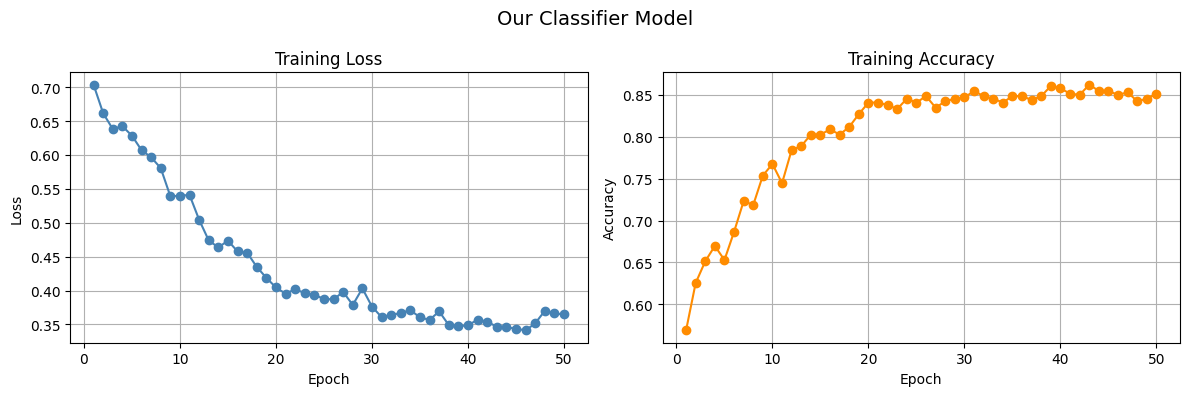

In [118]:
import matplotlib.pyplot as plt
%matplotlib inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, len(loaded["losses"]) + 1), loaded["losses"], marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, epochs+1), loaded["accs"], marker='o', color='darkorange')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

# ax3.plot(range(1, epochs+1), loaded["vals"], marker='o', color='darkorange')
# ax3.set_title('Testing Accuracy')
# ax3.set_xlabel('Epoch')
# ax3.set_ylabel('Accuracy')
# ax3.grid(True)

plt.suptitle('Our Classifier Model', fontsize=14)
plt.tight_layout()
#plt.savefig('/content/baseline_training_curves.png')
plt.show()